## Code for polished versions of Fig 5 - pangenome integration

### Haploid cenhap typing main figure 

In [1]:
### Read in Faith's haploid data results to a df 

import pandas as pd

df = pd.read_csv(
    '/private/home/fokamoto/centromere-haplotype-sampling-pipeline/plot_outputs/haploid_data.tsv',
    sep='\t'
)
#for col in df.columns:
    #print(col)


#### Whole genome, Haploid CenHap typing 

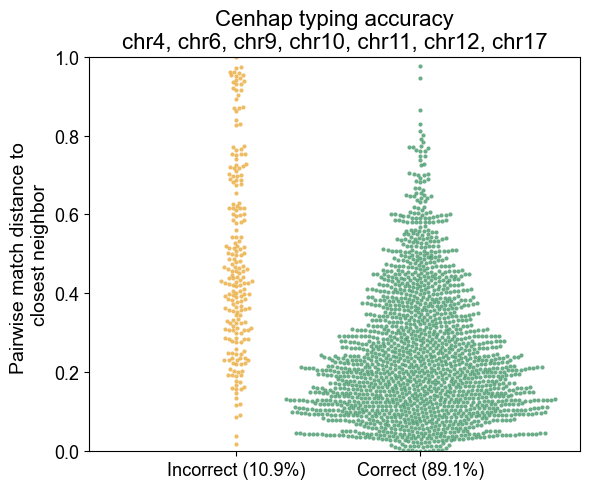

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

def swarmplot(xPos, yList, panel, color, pointSize, span, xRange, pW, yRange, pH):
    placedPoints = []
    minDist = (pointSize / 72) * 1.2
    increment = minDist / 20

    xList = []
    for shift in np.arange(0, span / 2, increment):
        xList.append(xPos + shift)
        xList.append(xPos - shift)

    for y1 in sorted(yList):
        placed = False
        if not placedPoints:
            placedPoints.append((xPos, y1))
            placed = True
        else:
            comparePoints = [
                (x2, y2) for x2, y2 in placedPoints
                if abs((y1 - y2) / yRange * pH) <= minDist
            ]
            if not comparePoints:
                placedPoints.append((xPos, y1))
                placed = True
            else:
                for x1 in xList:
                    if not placed:
                        dists = [
                            np.sqrt(((x1 - x2) / xRange * pW) ** 2 +
                                    ((y1 - y2) / yRange * pH) ** 2)
                            for x2, y2 in comparePoints
                        ]
                        if min(dists) > minDist:
                            placedPoints.append((x1, y1))
                            placed = True
        if not placed:
            placedPoints.append((xPos, y1))

    for x, y in placedPoints:
        x_noise = x + np.random.uniform(-increment / 2, increment / 2)
        panel.plot(x_noise, y, marker='o', ms=pointSize, mew=0, mfc=color, alpha=0.7, lw=0)

# ── data prep ─────────────────────────────────────────────────────────────────

filt_df = df.copy()
filt_df["Correctness"] = (filt_df["Truth cenhap"] == filt_df["Guessed cenhap"]).map({True: "Correct", False: "Incorrect"})

incorrect_vals = filt_df[filt_df["Correctness"] == "Incorrect"]["Minimum graph distance"].dropna().values
correct_vals   = filt_df[filt_df["Correctness"] == "Correct"]["Minimum graph distance"].dropna().values

n_total       = len(incorrect_vals) + len(correct_vals)
pct_incorrect = 100 * len(incorrect_vals) / n_total
pct_correct   = 100 * len(correct_vals)   / n_total

chroms = ', '.join(sorted(filt_df['Chromosome'].unique(),
                          key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 99))

# ── figure ────────────────────────────────────────────────────────────────────

pW, pH = 6, 5
fig, ax = plt.subplots(figsize=(pW, pH))

xmin, xmax, ymin, ymax = -1.5, 2.5, 0, 1
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

swarmplot(-0.3, incorrect_vals, ax, '#E6A024',   3, 2.2, xmax - xmin, pW, ymax - ymin, pH)
swarmplot(1.2, correct_vals,   ax, 'seagreen', 3, 2.2, xmax - xmin, pW, ymax - ymin, pH)

ax.set_xticks([-0.3, 1.2])
ax.set_xticklabels([f'Incorrect ({pct_incorrect:.1f}%)', f'Correct ({pct_correct:.1f}%)'], fontsize=13)
ax.set_ylabel("Pairwise match distance to \nclosest neighbor", fontsize=14)
ax.set_xlabel("")
ax.set_title(f"Cenhap typing accuracy\n{chroms}", fontsize=16)
ax.tick_params(axis='y', labelsize=13)

fig.tight_layout()
plt.show()



### Haploid read alignments  

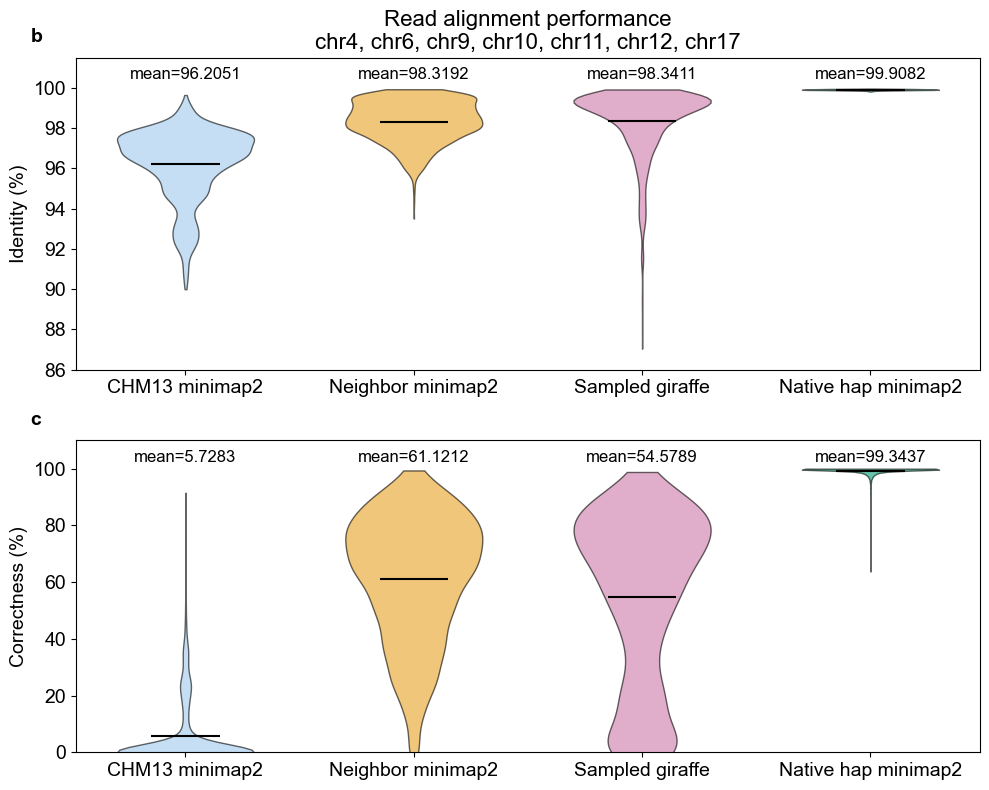

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Arial'

def filter_columns(header, col_type, real):
    cols = []
    for h in header:
        if col_type not in h:
            continue
        if real and 'sim' in h:
            continue
        if not real and 'real' in h:
            continue
        if 'minimap2' in h or 'Sampled giraffe' in h:
            cols.append(h)
    return cols

def violin_panel(ax, filt_df, cols, colors, ylabel, pW, pH, scale=1.0):
    for i, col in enumerate(cols):
        vals = pd.to_numeric(filt_df[col], errors='coerce').dropna().values * scale
        parts = ax.violinplot([vals], positions=[i], widths=0.6,
                              showmeans=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.6)
        parts['cmeans'].set_color('black')
        parts['cmeans'].set_linewidth(1.5)

        tmp = pd.DataFrame({'val': vals, '_pos': i})
        #sns.swarmplot(data=tmp, x='_pos', y='val', ax=ax,
        #              color=colors[i], size=2, alpha=0.6,
        #              native_scale=True)

        mean_val = np.mean(vals)
        ymin, ymax = ax.get_ylim()
        label_y = ymax - (ymax - ymin) * 0.03
        ax.annotate(f'mean={mean_val:.4f}', xy=(i, label_y),
                    ha='center', va='top', fontsize=12)

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([' '.join(c.split()[:-2]) for c in cols], fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

# ── data prep ─────────────────────────────────────────────────────────────────

header  = df.columns.tolist()
filt_df = df.copy()

id_cols  = filter_columns(header, 'identity',    real=True)
cor_cols = filter_columns(header, 'correctness', real=True)

color_map = {
    'CHM13 minimap2':      '#9FC9EB',
    'Neighbor minimap2':   '#E6A024',
    'Native hap minimap2': '#009E73',
    'Sampled giraffe':     '#CC79A7',
}
colors = [color_map.get(' '.join(c.split()[:-2]), '#aaaaaa') for c in id_cols]

chroms = ', '.join(sorted(filt_df['Chromosome'].unique(),
                          key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 99))

# ── figure ────────────────────────────────────────────────────────────────────

pW, pH = 10, 4
fig, (ax_b, ax_c) = plt.subplots(2, 1, figsize=(pW, pH * 2))
ax_b.set_ylim(86, 101.5)
ax_c.set_ylim(0, 110)
ax_b.set_title("")
ax_c.set_title("")
violin_panel(ax_b, filt_df, id_cols,  colors, "Identity (%)",    pW, pH, scale=100)
violin_panel(ax_c, filt_df, cor_cols, colors, "Correctness (%)", pW, pH,scale=1)

from matplotlib.ticker import FormatStrFormatter
ax_b.yaxis.set_major_formatter(FormatStrFormatter('%d'))

ax_b.set_title(f"Read alignment performance\n{chroms}", fontsize=16)

for ax, letter in zip([ax_b, ax_c], "bc"):
    ax.text(-0.05, 1.05, letter, transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()


### Visualizing typing confidence with scores

In [10]:
### Read in cenhap assignments 

import os
import pandas as pd

base_dir = '/private/groups/migalab/juklucas/centrolign/cenhap_assignment/cenhap_inference_out'

dfs = []
for chrom in os.listdir(base_dir):
    fpath = os.path.join(base_dir, chrom, f'{chrom}.cenhap_predictions.tsv')
    if os.path.isfile(fpath):
        tmp = pd.read_csv(fpath, sep='\t', names=['sample', 'cenhap'], header=0)
        tmp['chrom'] = chrom
        dfs.append(tmp)

cenhap_labels_df = pd.concat(dfs, ignore_index=True)[['chrom', 'sample', 'cenhap']]
print(cenhap_labels_df.shape)
cenhap_labels_df.head()


(3248, 3)


,chrom,sample,cenhap
0,chr11,GRCh38.0,10
1,chr11,HG00097.1,3
2,chr11,HG00097.2,3
3,chr11,HG00099.1,2
4,chr11,HG00099.2,6


In [11]:
def score_diff_next_best(row, cenhap_lookup):
    """
    For a row, find the difference between the top score and the next best
    score from a haplotype with a different cenhap than Guessed cenhap.
    """
    chrom        = row['Chromosome']
    guessed_cenhap = row['Guessed cenhap']

    # parse sampled names and scores
    names  = [s.strip() for s in str(row['Sampled haplotype names']).split(',')]
    scores = [float(s.strip()) for s in str(row['Sampled haplotype scores']).split(',')]

    if not names or not scores:
        return None

    # sort by score descending
    paired = sorted(zip(scores, names), reverse=True)
    top_score = paired[0][0]

    # find next best with a different cenhap
    for score, name in paired:
        cenhap = cenhap_lookup.get((chrom, name), None)
        if cenhap is None:
            continue
        if cenhap != guessed_cenhap:
            return top_score - score

    return None  # no alternative cenhap found

# build lookup dict from cenhap_labels_df
cenhap_lookup = {(row['chrom'], row['sample']): row['cenhap']
                 for _, row in cenhap_labels_df.iterrows()}

df['score_diff_next_diff_cenhap'] = df.apply(
    lambda row: score_diff_next_best(row, cenhap_lookup), axis=1
)

print(df['score_diff_next_diff_cenhap'].describe())
df[['Chromosome', 'Haplotype name', 'Guessed cenhap', 'score_diff_next_diff_cenhap']].head(10)


count    1096.000000
mean      382.879288
std       467.744286
min         0.000000
25%         6.100000
50%       229.300000
75%       555.750000
max      3232.000000
Name: score_diff_next_diff_cenhap, dtype: float64


,Chromosome,Haplotype name,Guessed cenhap,score_diff_next_diff_cenhap
0,chr11,HG00097.1,3,644.0
1,chr11,HG00097.2,3,0.0
2,chr11,HG00099.1,2,NaN
3,chr11,HG00126.1,2,NaN
4,chr11,HG00126.2,3,NaN
5,chr11,HG00128.1,3,NaN
6,chr11,HG00128.2,3,255.0
7,chr11,HG00133.1,3,NaN
8,chr11,HG00133.2,5,878.0
9,chr11,HG00140.1,5,95.0


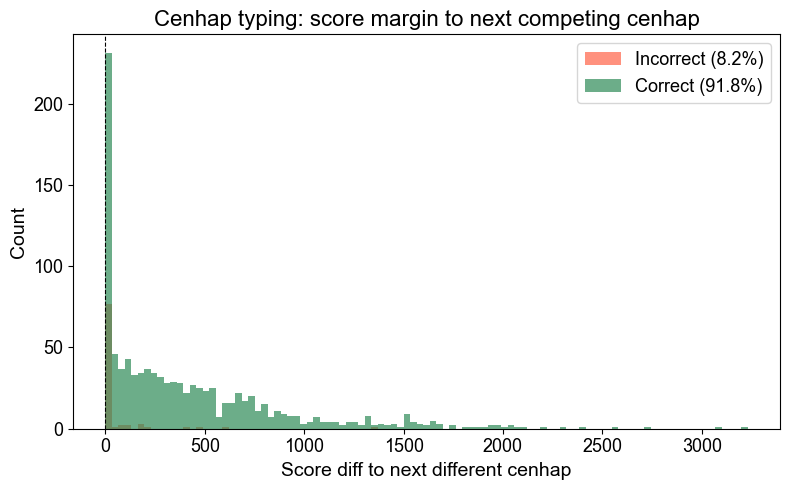

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(filt['score_diff_next_diff_cenhap'].min(),
                   filt['score_diff_next_diff_cenhap'].max(), 100)

ax.hist(incorrect_vals, bins=bins, color='tomato',   alpha=0.7, label=f'Incorrect ({pct_incorrect:.1f}%)')
ax.hist(correct_vals,   bins=bins, color='seagreen', alpha=0.7, label=f'Correct ({pct_correct:.1f}%)')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Score diff to next different cenhap", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
ax.set_title("Cenhap typing: score margin to next competing cenhap", fontsize=16)
ax.tick_params(labelsize=13)
ax.legend(fontsize=13)

fig.tight_layout()
plt.show()



### Diploid typing results

In [32]:
### Read in Faith's haploid data results to a df 

import pandas as pd

dip_df = pd.read_csv(
    '/private/home/fokamoto/centromere-haplotype-sampling-pipeline/plot_outputs/diploid_data.tsv',
    sep='\t'
)
for col in dip_df.columns:
    print(col)


Chromosome
Sample
Truth cenhaps
Guessed cenhaps


In [33]:
import re
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

def swarmplot(xPos, yList, panel, color, pointSize, span, xRange, pW, yRange, pH):
    placedPoints = []
    minDist = (pointSize / 72) * 1.2
    increment = minDist / 20

    xList = []
    for shift in np.arange(0, span / 2, increment):
        xList.append(xPos + shift)
        xList.append(xPos - shift)

    for y1 in sorted(yList):
        placed = False
        if not placedPoints:
            placedPoints.append((xPos, y1))
            placed = True
        else:
            comparePoints = [
                (x2, y2) for x2, y2 in placedPoints
                if abs((y1 - y2) / yRange * pH) <= minDist
            ]
            if not comparePoints:
                placedPoints.append((xPos, y1))
                placed = True
            else:
                for x1 in xList:
                    if not placed:
                        dists = [
                            np.sqrt(((x1 - x2) / xRange * pW) ** 2 +
                                    ((y1 - y2) / yRange * pH) ** 2)
                            for x2, y2 in comparePoints
                        ]
                        if min(dists) > minDist:
                            placedPoints.append((x1, y1))
                            placed = True
        if not placed:
            placedPoints.append((xPos, y1))

    for x, y in placedPoints:
        x_noise = x + np.random.uniform(-increment / 2, increment / 2)
        panel.plot(x_noise, y, marker='o', ms=pointSize, mew=0, mfc=color, alpha=0.7, lw=0)

# ── data prep ─────────────────────────────────────────────────────────────────

filt_df = dip_df.copy()
filt_df["Correctness"] = (filt_df["Truth cenhaps"] == filt_df["Guessed cenhaps"]).map({True: "Correct", False: "Incorrect"})

incorrect_vals = filt_df[filt_df["Correctness"] == "Incorrect"]["Minimum graph distance"].dropna().values
correct_vals   = filt_df[filt_df["Correctness"] == "Correct"]["Minimum graph distance"].dropna().values

n_total       = len(incorrect_vals) + len(correct_vals)
pct_incorrect = 100 * len(incorrect_vals) / n_total
pct_correct   = 100 * len(correct_vals)   / n_total

chroms = ', '.join(sorted(filt_df['Chromosome'].unique(),
                          key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 99))

# ── figure ────────────────────────────────────────────────────────────────────

pW, pH = 6, 5
fig, ax = plt.subplots(figsize=(pW, pH))

xmin, xmax, ymin, ymax = -1.5, 2.5, 0, 1
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

swarmplot(-0.5, incorrect_vals, ax, '#E6A024',   3, 2.2, xmax - xmin, pW, ymax - ymin, pH)
swarmplot(1.2, correct_vals,   ax, 'seagreen', 3, 2.2, xmax - xmin, pW, ymax - ymin, pH)

ax.set_xticks([-0.5, 1.2])
ax.set_xticklabels([f'Incorrect ({pct_incorrect:.1f}%)', f'Correct ({pct_correct:.1f}%)'], fontsize=13)
ax.set_ylabel("Pairwise match distance to \nclosest neighbor", fontsize=14)
ax.set_xlabel("")
ax.set_title(f"Diploid Cenhap typing accuracy\n{chroms}", fontsize=16)
ax.tick_params(axis='y', labelsize=13)

fig.tight_layout()
plt.show()


KeyError: 'Minimum graph distance'